# 🧠 ****Stroke Prediction using Machine Learning: Saving Lives with Data Science**** 🚑

Stroke is one of the leading causes of death and disability worldwide. Early detection and timely medical intervention can drastically reduce the risks associated with strokes. In this project, I use machine learning to predict the likelihood of a stroke in patients based on key health indicators and demographic features.

---

## 📌 **Project Highlights**
- ✅ **Data Preprocessing & Cleaning** – Handling missing values, outliers, and skewed data distributions.  
- ✅ **Exploratory Data Analysis (EDA)** – Uncovering trends in stroke prevalence across various groups.  
- ✅ **Feature Engineering & Selection** – Identifying and selecting the most influential features.  
- ✅ **Class Imbalance Handling** – Using SMOTE to balance the dataset for improved learning.  
- ✅ **Model Training & Evaluation** – Building and testing multiple models like SVM, Random Forest, Logistic Regression, and more.  
- ✅ **Performance Metrics Focus** – Prioritizing recall for better identification of at-risk patients.  


---

This project demonstrates the power of machine learning in making critical health predictions. With the help of clean data pipelines and robust models, I strive to contribute to life-saving decisions through data! 🧬📈

> 💡 *Healthcare isn’t just about treatment — it's about prediction and prevention. This project is a step toward that vision, one prediction at a time.*


##  Installing Required Libraries

I install the necessary packages to ensure our environment has the right tools for preprocessing, resampling, and building machine learning models.

- `scikit-learn` – Core machine learning library.
- `imbalanced-learn` – Tools like SMOTE to handle imbalanced datasets.


In [63]:
pip install --upgrade scikit-learn imbalanced-learn

##  Importing Required Libraries

I begin by importing all the necessary Python libraries for:

-  **Data Analysis & Visualization**: `pandas`, `numpy`, `seaborn`, `matplotlib`
-  **Preprocessing & Pipelines**: `scikit-learn` tools like `SimpleImputer`, `MinMaxScaler`, `OneHotEncoder`, and `Pipeline`
-  **Modeling**: Multiple ML models including `SVC`, `RandomForest`, `KNN`, `Logistic Regression`, etc.
-  **Class Imbalance Handling**: `SMOTE` from `imblearn`
-  **Feature Selection**: `SelectKBest` using `mutual_info_classif`
-  **Model Evaluation**: Metrics like `roc_auc_score`, `accuracy_score`, `recall_score`, and `classification_report`

This setup ensures we have all tools ready for data preprocessing, modeling, evaluation, and visualization.


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as IMBPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, classification_report
from imblearn.over_sampling import SMOTE

import time
import warnings
warnings.filterwarnings('ignore')



Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



## Data Loading and Initial Preview

I load the stroke dataset using `pandas` from the Kaggle-provided input directory. The dataset contains patient-level health information used to predict the likelihood of a stroke.

I will begin by loading the dataset and displaying the first few rows to understand the structure and types of data available.


In [65]:
df=pd.read_csv("../dataset/healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [66]:
df.shape

(5110, 12)

In [67]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

## Missing Values Analysis

Before performing any data preprocessing, it's essential to identify missing values. These can significantly affect model performance if not handled properly.

I will create a DataFrame to count the number of missing values in each column and display it in a transposed format for better readability.


In [68]:
missing_df=pd.DataFrame(df.isna().sum(),columns=['No.of Missing Values'])
missing_df.T

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
No.of Missing Values,0,0,0,0,0,0,0,0,0,201,0,0


##  Handling Missing BMI Values

The `bmi` column contains missing values. Since `bmi` is a numerical variable and likely to be skewed, I will handle its missing values using the **median**, which is more robust to outliers than the mean.

This step ensures our dataset has no missing values before moving to the next stage.


In [69]:
df['bmi'].fillna(df['bmi'].median(),inplace=True)


## Verifying Missing Values After Imputation

After filling missing values in the `bmi` column using the median, I'll now verify that no missing data remains in the dataset. This is a crucial step to ensure the data is clean and ready for preprocessing or analysis.

The output below will show a summary of any remaining missing values across all columns.


In [70]:
missing_df=pd.DataFrame(df.isna().sum(),columns=['No.of Missing Values'])
missing_df.T

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
No.of Missing Values,0,0,0,0,0,0,0,0,0,0,0,0


## Checking Data Types of Each Column

Understanding the data types of each column is essential for deciding the right preprocessing techniques. For example, numerical columns might require scaling, while categorical ones may need encoding.

The code below transposes the data types for a cleaner, more readable view.


In [71]:
df.dtypes.to_frame().T

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,int64,object,float64,int64,int64,object,object,object,float64,float64,object,int64


##  Converting Age to Integer Format

The `age` column was originally in float format (e.g., 67.0), which isn't semantically necessary for age values. I convert it to integer to better reflect the nature of the data and to simplify further analysis or modeling steps.

Let's convert the age column and verify the data types again.


In [72]:
df['age']=df['age'].astype(int)
df.dtypes.to_frame().T

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,int64,object,int32,int64,int64,object,object,object,float64,float64,object,int64


##  Dataset Information Overview

I use `df.info()` to get a concise summary of the dataset, which includes:
- Total number of entries (rows)
- Number of columns
- Data types of each column
- Number of non-null (non-missing) values
- Memory usage

This helps us quickly assess data completeness and structure before proceeding further.


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   int32  
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(2), int32(1), int64(4), object(5)
memory usage: 459.2+ KB


## Descriptive Statistics Summary

I use `df.describe()` to generate summary statistics of the numerical features in the dataset. It provides:
- **Count**: Number of non-null values
- **Mean**: Average of the column
- **Standard deviation (std)**: Spread of the data
- **Min/Max**: Minimum and maximum values
- **25%, 50%, 75%**: Quartile values (used later for outlier detection)

This helps us understand the central tendency and distribution of each numeric feature.


In [74]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,36517.829354,43.215264,0.097456,0.054012,106.147677,28.862035,0.048728
std,21161.721625,22.633866,0.296607,0.226063,45.283560,7.699562,0.215320
min,67.000000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


##  Checking for Duplicate Records

I use `df.duplicated().sum()` to identify any **duplicate rows** in the dataset.

- **Why it's important**: Duplicate entries can skew our analysis and model performance by over-representing certain data points.
- **Action**: If duplicates are found, I may drop them using `df.drop_duplicates()` to ensure data integrity.


In [75]:
print("Duplicate rows in a dataset:",df.duplicated().sum())

Duplicate rows in a dataset: 0


## Gender Distribution Overview

I examine the distribution of values in the `gender` column using `df.gender.value_counts().to_frame().T`.

- **Purpose**: Understand the count of each gender category in the dataset.
- **Insight**: Helps us verify if the data is balanced across genders or if there's an imbalance that might affect modeling.


In [76]:
df.gender.value_counts().to_frame().T

,Female,Male,Other
gender,2994,2115,1


##  Data Cleaning: Dropping Unnecessary and Rare Categories

I performed two important cleaning steps:

1. **Removed the `id` column**:
   - `df.drop('id', axis=1, inplace=True)`
   - Reason: The `id` column is just a unique identifier and does not contribute to prediction, so I dropped it.

2. **Removed rows where `gender` is labeled as 'Other'**:
   - Reason: This category has very few records and might introduce noise or instability in model training.


In [77]:
df.drop('id',axis=1,inplace=True)
df.drop(df[df['gender']=='Other'].index,inplace=True)

##  Gender Distribution After Cleaning

I rechecked the distribution of the `gender` column after removing the rare `'Other'` category 


In [78]:
df.gender.value_counts().to_frame().T

,Female,Male
gender,2994,2115


## Target Variable Distribution – Stroke Cases

To understand the imbalance in our target variable `stroke`, I calculated the normalized value counts:


In [79]:
df['stroke'].value_counts(normalize=True).to_frame().T

,0,1
stroke,0.951262,0.048738


##  Outlier Detection using Boxplots

I used boxplots to visually inspect the presence of **outliers** in key numerical features: `age`, `avg_glucose_level`, and `bmi`.

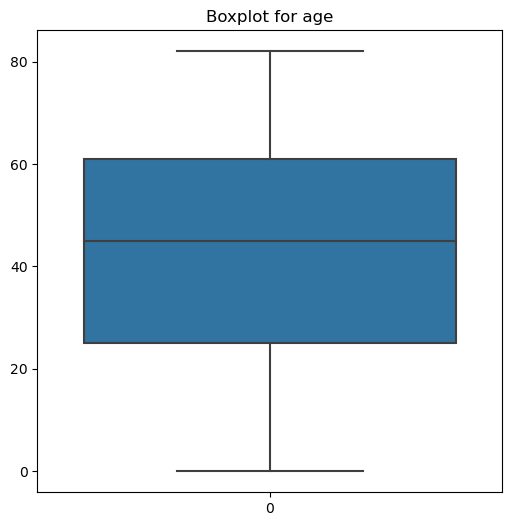

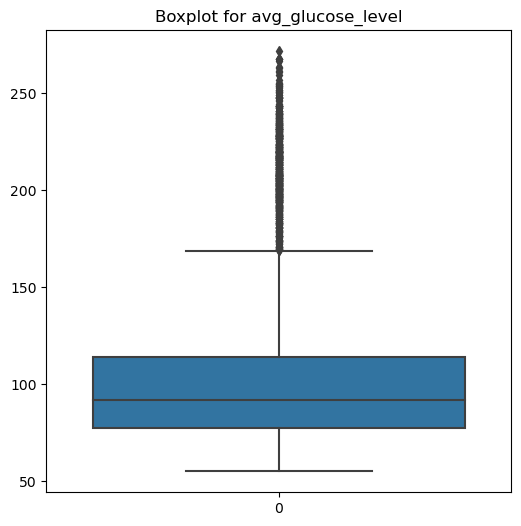

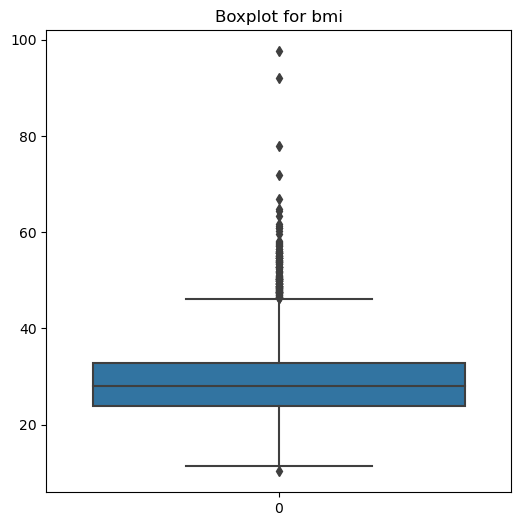

In [80]:
features = ['age', 'avg_glucose_level', 'bmi']
for i in features:
    plt.figure(figsize=(6,6))
    sns.boxplot(df[i])
    plt.title(f'Boxplot for {i}')
    plt.show()

##  Outlier Count Using IQR Method

To quantify outliers in the dataset, I used the **Interquartile Range (IQR) method**. The IQR method identifies data points that lie significantly below the 1st quartile (Q1) or above the 3rd quartile (Q3).




In [81]:
def iqrm(series):
    q1 = np.percentile(series, 25)
    q3 = np.percentile(series, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers)


a1 = iqrm(df['age'])
a2 = iqrm(df['avg_glucose_level'])
a3 = iqrm(df['bmi'])

print("Outliers in age:", a1)
print("Outliers in avg_glucose_level:", a2)
print("Outliers in bmi:", a3)


Outliers in age: 0
Outliers in avg_glucose_level: 627
Outliers in bmi: 126


##  Skewness Analysis

Skewness measures the **asymmetry** of the distribution of a dataset. A skewness value:

- Close to **0** indicates a fairly **symmetrical** distribution.
- **Positive skew** (> 0) means the tail is longer on the **right side** (right-skewed).
- **Negative skew** (< 0) means the tail is longer on the **left side** (left-skewed).



In [82]:
print('Skewness for bmi column:',df['bmi'].skew())
print('Skewness for avg_glucose_level column:',df['avg_glucose_level'].skew())

Skewness for bmi column: 1.0879286872396872
Skewness for avg_glucose_level column: 1.5728153284961561


##  Outlier Treatment Using Winsorization

To manage outliers in the numerical features, I apply **Winsorization**.  
Winsorization caps the extreme values of the distribution at specific percentile thresholds to reduce the impact of outliers **without removing any data**.

I apply it to both `bmi` and `avg_glucose_level` columns.



In [83]:
def winsorization(df, column, lower_percentile=5, upper_percentile=95):
    lower = np.percentile(df[column], lower_percentile)
    upper = np.percentile(df[column], upper_percentile)
    df[column] = np.where(df[column] < lower, lower, df[column])
    df[column] = np.where(df[column] > upper, upper, df[column])
    return df

df=winsorization(df,'bmi')
df=winsorization(df,'avg_glucose_level')


##  Rechecking Outliers After Winsorization

After applying Winsorization, I re-evaluate the number of outliers in the `avg_glucose_level` and `bmi` columns using the **Interquartile Range (IQR) method**.

This helps verify whether our outlier capping was effective.


In [84]:

print("Outliers in avg_glucose_level:", iqrm(df['avg_glucose_level']))
print("Outliers in bmi:", iqrm(df['bmi']))


Outliers in avg_glucose_level: 627
Outliers in bmi: 0


## Log Transformation on `avg_glucose_level`

Even after Winsorization, some outliers may persist due to **high skewness** in the `avg_glucose_level` distribution.  
To further reduce the impact of these outliers and bring the data closer to a normal distribution, I apply a **logarithmic transformation** using `np.log1p()`.

### Why `np.log1p()`?
- It computes `log(1 + x)`, which is numerically stable and works well even if the column contains zeros.
- It reduces **right skewness**, making the data more suitable for models that assume normality.


In [85]:
df['avg_glucose_level'] = np.log1p(df['avg_glucose_level'])  


##  Rechecking Outliers in `avg_glucose_level` After Log Transformation

After applying `log1p` transformation to reduce skewness, I'll now **recalculate the number of outliers** in the `avg_glucose_level` column using the IQR method.  
This helps verify whether the transformation effectively reduced extreme values.


In [86]:
a2 = iqrm(df['avg_glucose_level'])
print("Outliers in avg_glucose_level:", a2)

Outliers in avg_glucose_level: 384


##  Outliers in `avg_glucose_level` — Retained Intentionally

After applying **Winsorization** and a **logarithmic transformation**, some outliers still remain in the `avg_glucose_level` column.  
However, instead of aggressively removing them, I have chosen to **retain these outliers** for the following reasons:

 **Importance in Healthcare Domain**  
In medical datasets, outliers often correspond to **critical or rare medical conditions**.  
For example, extremely high glucose levels may indicate **severe diabetes or metabolic disorders**, and removing them could **hide important patterns** relevant for stroke prediction.

 **Balanced Approach**  
I have already **reduced extreme values** through preprocessing to prevent their undue influence, while still **preserving key information**.  
This strikes a balance between data quality and medical insight.

 **Conclusion**: Outliers are present, but they are **domain-relevant and informative**, so I’ve chosen to keep them in the dataset.


##  Skewness of `avg_glucose_level` After Log Transformation

I'll now calculate the **skewness** of the `avg_glucose_level` column after applying the `log1p` transformation.  
This transformation is used to **reduce the effect of extreme values** and **normalize** the distribution.


In [87]:
print('Skewness for avg_glucose_level column after applying log transformation : ',df['avg_glucose_level'].skew())

Skewness for avg_glucose_level column after applying log transformation :  0.8647619792459227


##  Correlation with Target Variable (`stroke`)

To understand the linear relationship between the target variable (`stroke`) and all other features, I calculated the **Pearson correlation coefficients** using the `corr()` method.


In [90]:
correlation=df.corr()['stroke'].sort_values(ascending=False).to_frame().T
correlation

,stroke,age,heart_disease,hypertension,avg_glucose_level,bmi
stroke,1.0,0.245109,0.134905,0.127891,0.115562,0.04335


##  Visualizing Feature Correlation with Stroke

To get an intuitive view of how each feature correlates with the target variable `stroke`, I created a **horizontal bar plot** using Seaborn. This helps quickly identify which features are more relevant for predicting strokes based on their linear correlation.


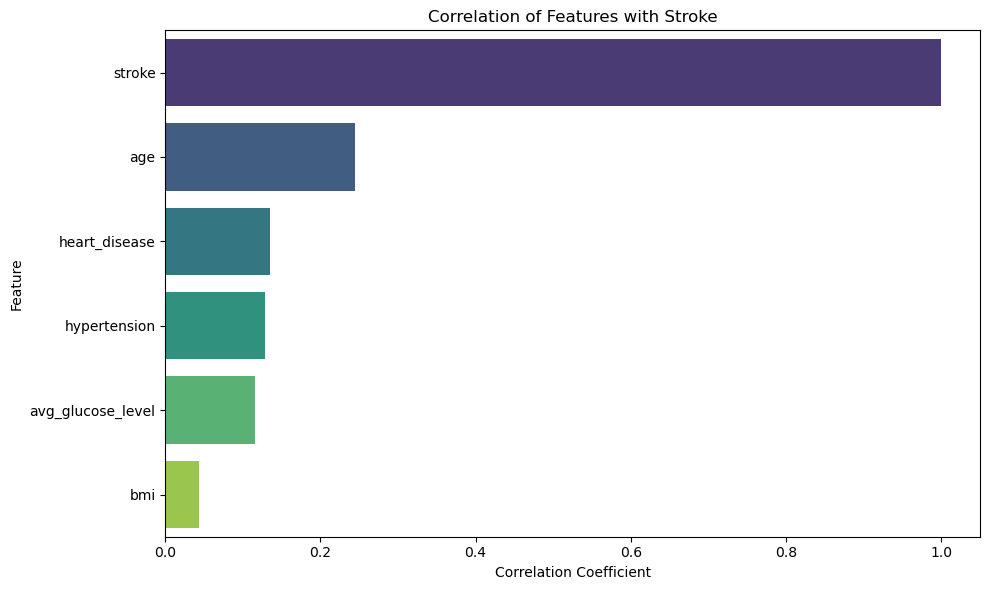

In [91]:
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation.values.flatten(), y=correlation.columns, palette="viridis")
plt.title("Correlation of Features with Stroke")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


##  Separating Features and Target

I'll now separate our dataset into:

- **`X`** – the feature matrix (all columns except `stroke`)
- **`y`** – the target vector (the `stroke` column)

This prepares the data for further steps like feature selection, class balancing, and model training.

In [110]:
X=df.drop(columns=['stroke','work_type','Residence_type','ever_married','smoking_status'],axis=1)
y=df['stroke']


##  Train-Test Split

I'll now split our dataset into training and testing sets:

- **Training Set**: Used to train the machine learning model.
- **Testing Set**: Used to evaluate the model's performance on unseen data.

I am using an 80-20 split, with a fixed random seed for reproducibility.

In [111]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=7)

##  Reusable Machine Learning Pipeline Function

Although I have already completed the preprocessing steps earlier in this project, I created a **modular and reusable pipeline function** that is designed to be used across **any machine learning project** — regardless of the dataset or domain.

###  Why This Pipeline Is Universal:

-  **Handles both numerical and categorical features** automatically by detecting their types.
-  **Scales** numerical features and **imputes** missing values in a robust and customizable way.
-  **Balances imbalanced datasets** using SMOTE, which is especially useful in real-world problems like fraud detection, medical diagnoses, etc.
-  **Selects top features** using `SelectKBest` and `mutual_info_classif`, which can be replaced with any scoring function depending on the task.
-  **Wraps the model inside a full pipeline**, making training, cross-validation, and evaluation clean and consistent.

>  **Note**: While this pipeline was applied to a healthcare stroke prediction dataset, it is written in a generic format and can be directly reused for any supervised learning task with minimal changes.

This promotes **code reusability, modularity, and cleaner workflow**, which are best practices in professional machine learning projects.


##  Model Pipeline Creation

I define a custom pipeline function that integrates all key steps in a typical machine learning workflow:

###  Steps Included:

1. **Numerical Preprocessing**
   - Missing value imputation using a median strategy.
   - Scaling using Min-Max Scaler to bring all values between 0 and 1.

2. **Categorical Preprocessing**
   - Missing values filled using the most frequent category.
   - One-hot encoding to convert categorical variables into numerical format.

3. **Column Transformer**
   - Combines numerical and categorical pipelines.
   - Passes through any remaining columns untouched (`remainder='passthrough'`).

4. **SMOTE Oversampling**
   - Balances the target classes to avoid bias toward the majority class.

5. **Feature Selection**
   - Uses Mutual Information (`mutual_info_classif`) to select top 7 features most relevant to the target.

6. **Model Training**
   - Adds the specified model as the final step in the pipeline.




In [112]:
def model_pipeline(X,model):
    numerical_features=X.select_dtypes(exclude=['object']).columns.to_list()
    categorical_features=X.select_dtypes(include=['object']).columns.to_list()
    numerical_pipeline=Pipeline([
        ('Imputer',SimpleImputer(strategy='median')),
        ('Scaler',MinMaxScaler())
    ])
    categorical_pipeline=Pipeline([
        ('Imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
    ])
    preprocessor=ColumnTransformer([
        ('numeric',numerical_pipeline,numerical_features),
        ('categorical',categorical_pipeline,categorical_features)        
    ],remainder='passthrough')
    final_steps=[
        ('preprocessor',preprocessor),
        ('smote',SMOTE(sampling_strategy=0.2,random_state=7)),
        ('feature_selection',SelectKBest(score_func=mutual_info_classif,k=7)),
        ('model',model)
    ]
    return IMBPipeline(steps = final_steps)

##  Automated Model Selection and Evaluation Function

In this step, I define a **flexible model evaluation function** that helps us **compare multiple machine learning models** using consistent preprocessing and scoring metrics.

###  Key Highlights of `select_model()`:

-  **Reusable for any classification task**.
-  Automatically runs a predefined set of classifiers (or a custom model) through the complete pipeline.
-  Tracks execution time for each model for performance comparison.
-  Uses **10-fold cross-validation** to ensure robust model evaluation.
-  Evaluates models based on **ROC-AUC score**, which is particularly suitable for **imbalanced classification problems**, like in this healthcare dataset.

###  Models Evaluated:
- Random Forest
- Decision Tree
- K-Nearest Neighbors
- Bernoulli Naive Bayes
- Support Vector Classifier (SVC)
- Logistic Regression

>  **Custom Model Option**: You can pass a custom model using the `model` parameter to evaluate just that one model with the same pipeline and scoring.

This function simplifies **model benchmarking** and helps identify which algorithms perform best before proceeding with **hyperparameter tuning or deployment**.


In [113]:

def select_model(X, y,model=None):
    if  model==None:
        classifiers = {"RandomForestClassifier": RandomForestClassifier(),
                      "DecisionTreeClassifier": DecisionTreeClassifier(),
                      "KNeighborsClassifier": KNeighborsClassifier(),
                      "BernoulliNB": BernoulliNB(),
                      "SVC": SVC(),
                      'LogisticRegression':LogisticRegression()
                      }
    else:
        classifiers={str(model):model}
    cols = ['model', 'run_time', 'roc_auc']
    df_models = pd.DataFrame(columns = cols)
    for key in classifiers:
        start_time = time.time()
        print()
        print(" model_pipeline running on", key)
        pipeline = model_pipeline(X, classifiers[key])
        cv = cross_val_score(pipeline, X, y, cv=10, scoring='roc_auc', error_score='raise')
        row = {'model': key,
               'run_time': format(round((time.time() - start_time)/60,2)),
               'roc_auc': cv.mean(),
        }
        df_models = pd.concat([df_models, pd.DataFrame([row])], ignore_index=True)   
    df_models = df_models.sort_values(by='roc_auc', ascending=False)
    return df_models

##  Running Model Comparison on Training Data

Now I run the `select_model()` function on our training data (`X_train`, `y_train`) to evaluate multiple classification algorithms using the same preprocessing pipeline.

###  Objective:
Identify the best-performing model based on **ROC-AUC score**, which is ideal for our **imbalanced healthcare dataset** where identifying stroke patients (class 1) is more critical than overall accuracy.

###  What Happens Under the Hood:
- The pipeline applies imputation, scaling, one-hot encoding, SMOTE oversampling, and feature selection.
- Each model is evaluated using **10-fold cross-validation** for robust comparison.
- Metrics recorded:
  - Model name
  - Time taken to train and evaluate
  - Average ROC-AUC score across folds

This step helps us **shortlist the best model** to fine-tune further.


In [114]:
models=select_model(X_train,y_train)


 model_pipeline running on RandomForestClassifier

 model_pipeline running on DecisionTreeClassifier

 model_pipeline running on KNeighborsClassifier

 model_pipeline running on BernoulliNB

 model_pipeline running on SVC

 model_pipeline running on LogisticRegression


In [115]:
print(models)

                    model run_time   roc_auc
5      LogisticRegression     0.12  0.842786
0  RandomForestClassifier     0.27  0.794401
4                     SVC     0.36  0.737661
2    KNeighborsClassifier     0.09  0.677028
3             BernoulliNB     0.08  0.650563
1  DecisionTreeClassifier      0.1  0.621484


##  Hyperparameter Tuning for Logistic Regression

After identifying Logistic Regression as a high-performing model, I proceed to fine-tune its hyperparameters using **RandomizedSearchCV**.

### Tuning Strategy:
I define a hyperparameter search space and use randomized search (faster than grid search for large spaces) to find the best combination.

#### Parameters Tuned:
- `C`: Inverse of regularization strength (lower values imply stronger regularization).
- `penalty`: Type of regularization (`l1` or `l2`).
- `solver`: Algorithm used for optimization (`liblinear` and `saga` support both penalties).
- `class_weight`: Set to `'balanced'` to handle class imbalance.
- `max_iter`: Max iterations for convergence.

###  Cross-Validation:
I use **5-fold cross-validation** and evaluate based on **ROC-AUC** score.

The best combination of hyperparameters is printed along with the best score obtained, which will be used for model retraining.


In [116]:
lrpipe=model_pipeline(X_train, LogisticRegression())
d={
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga'],
    'model__class_weight': ['balanced'],
    'model__max_iter': [500,1000]
}
crf=RandomizedSearchCV(lrpipe,d,cv=5,scoring='roc_auc')
crf.fit(X_train,y_train)

,estimator,Pipeline(step...egression())])
,param_distributions,"{'model__C': [0.01, 0.1, ...], 'model__class_weight': ['balanced'], 'model__max_iter': [500, 1000], 'model__penalty': ['l1', 'l2'], ...}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


## Extracting the Best Tuned Pipeline

After completing hyperparameter tuning using **RandomizedSearchCV**, the best-performing pipeline configuration is extracted using `best_estimator_`.

The `best_score_` represents the mean cross-validated **ROC-AUC** score achieved during tuning. For better interpretability, the score is multiplied by 100 to express it as a percentage.

The `best_params_` shows the optimal hyperparameter combination selected for the **Logistic Regression** model within the pipeline.

This optimized pipeline will now be used for final evaluation on the unseen test dataset.

In [117]:
best_model = crf.best_estimator_

print("Best Score:", crf.best_score_*100)
print("Best Parameters:", crf.best_params_)

Best Score: 84.37627042704165
Best Parameters: {'model__solver': 'saga', 'model__penalty': 'l1', 'model__max_iter': 500, 'model__class_weight': 'balanced', 'model__C': 0.1}


###  Making Predictions on the Test Set

Once the final model (Logistic Regression) was trained on the preprocessed training data, I used it to make predictions on the **unseen test data**. This step evaluates how well the model generalizes to new, real-world samples.


In [118]:
y_pred=best_model.predict(X_test)

### Model Evaluation Metrics

To assess the performance of our final model, I calculated key evaluation metrics:

- **ROC AUC Score**: Measures the model's ability to distinguish between classes.
- **Accuracy**: Proportion of correct predictions over total predictions.
- **Recall**: Especially important in healthcare — it tells us how many actual positive cases (stroke patients) were correctly identified by the model.

> For better interpretability, scores is multiplied by 100 to express it as a percentage.


In [119]:
roc_auc = roc_auc_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print('ROC/AUC:', roc_auc*100)
print('Accuracy:', accuracy*100)
print('recall score:',recall*100)


ROC/AUC: 79.01440329218106
Accuracy: 76.32093933463796
recall score: 82.0


## 🚀 Deployment Pipeline (Without SMOTE)

After completing hyperparameter tuning and model evaluation, we create a separate **deployment pipeline**.

Unlike the training pipeline, this version excludes `SMOTE`, since oversampling is only required during training and should not be used during real-time inference.

### Why Remove SMOTE?

SMOTE generates synthetic samples for class balancing.

It is useful during training to handle class imbalance.

In deployment, we predict on real-world incoming data, not resampled data.

Therefore, SMOTE must be removed from the inference pipeline.

In [121]:
def deployment_pipeline(X, model):
    numerical_features = X.select_dtypes(exclude=['object']).columns.to_list()
    categorical_features = X.select_dtypes(include=['object']).columns.to_list()

    numerical_pipeline = Pipeline([
        ('Imputer', SimpleImputer(strategy='median')),
        ('Scaler', MinMaxScaler())
    ])

    categorical_pipeline = Pipeline([
        ('Imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer([
        ('numeric', numerical_pipeline, numerical_features),
        ('categorical', categorical_pipeline, categorical_features)
    ], remainder='passthrough')

    final_steps = [
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(score_func=mutual_info_classif, k=7)),
        ('model', model)
    ]

    return Pipeline(steps=final_steps)

## Extracting the Tuned Model from the Pipeline

After performing hyperparameter tuning using `RandomizedSearchCV`, the `best_estimator_` contains the **entire optimized pipeline**, including preprocessing steps and the trained model.

To rebuild a deployment-ready pipeline (without SMOTE), we need to extract only the tuned classifier.

### What This Does

`best_model` → The best pipeline returned by RandomizedSearchCV

`named_steps['model']` → Accesses the final step of the pipeline

`best_lr` → Stores the optimized Logistic Regression model with the best hyperparameters

In [122]:
best_lr = best_model.named_steps['model']


## Training the Final Deployment Pipeline

After extracting the tuned **Logistic Regression** model, we rebuild a clean **deployment pipeline (without SMOTE)** and train it on the full training dataset.

In [123]:
deploy_pipe = deployment_pipeline(X_train, best_lr)

deploy_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Saving the Final Deployment Model

After training the deployment-ready pipeline, the next step is to **serialize** the model so it can be reused for real-time predictions without retraining.

### What This Does

**joblib.dump()** saves the entire trained pipeline to a file.

The file **"stroke_prediction_model.pkl"** contains:

Preprocessing steps (imputation, scaling, encoding)

Feature selection logic

The trained Logistic Regression model

This ensures the exact same transformations are applied during inference.

In [127]:
import joblib
joblib.dump(deploy_pipe, "../stroke_prediction_model.pkl")

['../stroke_prediction_model.pkl']

## 🙏 Thank You for Visiting!

Thank you for taking the time to explore my stroke prediction project. I hope this notebook provided valuable insights into how machine learning can be applied in the healthcare domain to support early diagnosis and decision-making.

If you found this useful, feel free to leave feedback, suggestions, or connect with me for collaboration or discussions. Your support and input are greatly appreciated! 🤝

### 📌 **Contact Details:**  

🔗 **Kaggle**: https://www.kaggle.com/deepak48 
🔗 **LinkedIn**: https://www.linkedin.com/in/nagadeepak/  
✉️ **Email**: deepak48.ai@gmail.com 

---

*Machine learning isn't just about models — it's about impact. In healthcare, every correct prediction could help save a life.* ❤️‍🩹
